## Import Required Libraries

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.transform import resize
import os

## Load Dataset

In [8]:
# Load the training dataset
data_train = np.load('data/wafermap_train.npy', allow_pickle=True)
df_train = pd.DataFrame(data_train)

print("DataFrame Shape:", df_train.shape)
print("\nColumn Names:")
print(df_train.columns.tolist())
df_train.head()

DataFrame Shape: (2746, 6)

Column Names:
['dieSize', 'failureType', 'lotName', 'trainTestLabel', 'waferIndex', 'waferMap']


,dieSize,failureType,lotName,trainTestLabel,waferIndex,waferMap
0,3203.0,Center,lot10006,Training,5.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
1,1250.0,Center,lot10067,Training,9.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
2,2393.0,Center,lot10731,Training,9.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
3,2393.0,Center,lot10742,Training,25.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
4,2393.0,Center,lot10813,Training,12.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


## Data Preparation (Part 1)

According to the homework requirements:
- Resize all wafer maps to (64, 64)
- Convert the failure type string to numerical value

These functions and code are taken from Homework 3.

### Create String to Integer Mapping for Failure Types

In [9]:
# Create dictionary for converting failure type strings to numeric values
# This mapping is consistent with HW3
string2int = {
    'Center': 0,
    'Donut': 1,
    'Edge-Loc': 2,
    'Near-full': 3,
    'Scratch': 4
}

# Create reverse mapping for converting back to strings
int2string = {v: k for k, v in string2int.items()}

print("Failure Type Mapping:")
for failure_type, numeric_value in string2int.items():
    print(f"{failure_type} -> {numeric_value}")

Failure Type Mapping:
Center -> 0
Donut -> 1
Edge-Loc -> 2
Near-full -> 3
Scratch -> 4


### Define Data Preparation Functions

In [10]:
def convert_failure_type(failure_type: str) -> int:
    """Convert failure type string to numeric value."""
    return string2int[failure_type]

def resize_wafer_map(wafer_map: np.ndarray, output_shape: tuple=(64, 64)) -> np.ndarray:
    """Resize wafer map to specified shape.
    
    Args:
        wafer_map: Input wafer map array
        output_shape: Target shape (default: (64, 64))
    
    Returns:
        Resized wafer map array
    """
    return resize(wafer_map, output_shape, order=0, anti_aliasing=False, preserve_range=True)

### Apply Data Preparation

In [11]:
# Apply resize_wafer_map to create resizedWaferMap column
df_train['resizedWaferMap'] = df_train['waferMap'].apply(lambda x: resize_wafer_map(x))

# Apply convert_failure_type to create numericFailureType column
df_train['numericFailureType'] = df_train['failureType'].apply(convert_failure_type)

print("Data Preparation Complete!")
print(f"\nResized wafer map shape: {df_train['resizedWaferMap'].iloc[0].shape}")
print(f"\nFailure Type Distribution:")
print(df_train[['failureType', 'numericFailureType']].drop_duplicates().sort_values('numericFailureType'))

Data Preparation Complete!

Resized wafer map shape: (64, 64)

Failure Type Distribution:
     failureType  numericFailureType
0         Center                   0
2343       Donut                   1
771     Edge-Loc                   2
2731   Near-full                   3
1930     Scratch                   4


### Verify Data Preparation

Verification:
Number of samples: 2746
Resized wafer map shape: (64, 64)

Numeric failure types:
numericFailureType
0     771
1     388
2    1159
3      15
4     413
Name: count, dtype: int64


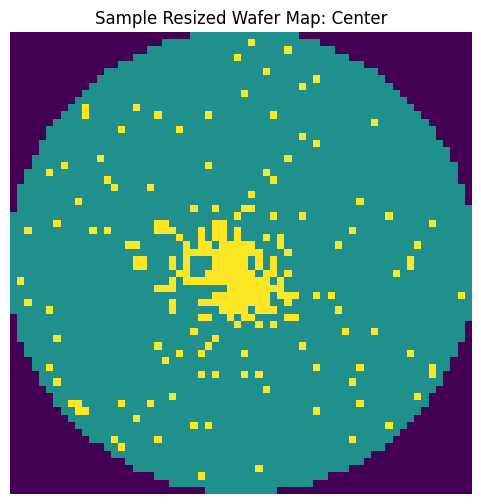

In [12]:
# Verify the resized wafer maps
print("Verification:")
print(f"Number of samples: {len(df_train)}")
print(f"Resized wafer map shape: {df_train['resizedWaferMap'].iloc[0].shape}")
print(f"\nNumeric failure types:")
print(df_train['numericFailureType'].value_counts().sort_index())

# Display a sample resized wafer map
plt.figure(figsize=(6, 6))
plt.imshow(df_train['resizedWaferMap'].iloc[0], cmap='viridis', vmin=0, vmax=2)
plt.title(f"Sample Resized Wafer Map: {df_train['failureType'].iloc[0]}")
plt.axis('off')
plt.show()

## Next Steps

The data preparation (Part 1) is complete. The next steps according to the homework are:

1. **Feature Engineering**: Create features for the wafer maps
2. **Data Preparation (Part 2)**: Select features and prepare dataset for training and validation
3. **Model Training and Validation**: Select model, train, and tune hyperparameters
4. **Model Testing**: Load test dataset, preprocess, predict, and output to scores.csv

## Feature Engineering

According to the homework requirements, we need to create features for the wafer maps. We'll use the same feature extraction functions from Homework 3.

The 10 geometric features are:
1. **Area Ratio**: Ratio of salient region area to wafer area
2. **Perimeter Ratio**: Ratio of salient region perimeter to wafer radius
3. **Max Distance from Center**: Maximum distance of salient region from wafer center
4. **Min Distance from Center**: Minimum distance of salient region from wafer center
5. **Major Axis Ratio**: Ratio of major axis of fitted ellipse to wafer radius
6. **Minor Axis Ratio**: Ratio of minor axis of fitted ellipse to wafer radius
7. **Solidity**: Proportion of salient region in its convex hull
8. **Eccentricity**: Shape of fitted ellipse (0=circle, 1=line)
9. **Yield Loss**: Ratio of failed dies to total dies
10. **Edge Yield Loss**: Ratio of failed dies at wafer edge to total edge dies

### Additional Imports for Feature Extraction

In [13]:
# Additional imports for feature extraction (from HW3)
from skimage.measure import label, regionprops, perimeter
from skimage.morphology import binary_erosion, square

# Define constants for wafer map values (from HW3)
NO_DIE = 0
PASS = 1
FAIL = 2

print("Feature extraction libraries imported successfully")

Feature extraction libraries imported successfully


### Step 1: Extract Salient Region

The salient region is the largest connected component of failing dies on each wafer map.

In [14]:
def get_salient_region(row: pd.Series) -> np.ndarray:
    """Extract the largest connected component of failing dies (salient region).
    
    Args:
        row: DataFrame row containing 'resizedWaferMap'
        
    Returns:
        Binary numpy array where 1 = salient region, 0 = background
    """
    wafer_map = row['resizedWaferMap']
    
    # Create binary mask of failing dies (value = 2)
    fail_mask = (wafer_map == FAIL).astype(int)
    
    # Label connected components with 8-connectivity (connectivity=2)
    labeled_regions = label(fail_mask, connectivity=2)
    
    # If no failing dies, return empty mask
    if labeled_regions.max() == 0:
        return np.zeros_like(wafer_map, dtype=int)
    
    # Get properties of all regions
    regions = regionprops(labeled_regions)
    
    # Find the region with the largest area
    largest_region = max(regions, key=lambda r: r.area)
    
    # Create binary mask for the salient region
    salient_region = (labeled_regions == largest_region.label).astype(int)
    
    return salient_region

# Apply to training data
print("Extracting salient regions...")
df_train['salientRegion'] = df_train.apply(get_salient_region, axis=1)
print(f"✓ Salient region column added")

Extracting salient regions...
✓ Salient region column added


### Step 2: Define All Feature Extraction Functions (from HW3)

In [15]:
def get_area_ratio(row: pd.Series) -> float:
    """Calculate ratio of salient region area to total wafer area."""
    salient_region = row['salientRegion']
    wafer_map = row['resizedWaferMap']
    
    salient_area = np.sum(salient_region)
    total_wafer_area = np.sum((wafer_map == PASS) | (wafer_map == FAIL))
    
    if total_wafer_area == 0:
        return 0.0
    
    return salient_area / total_wafer_area


def get_perimeter_ratio(row: pd.Series) -> float:
    """Calculate ratio of salient region perimeter to wafer radius."""
    salient_region = row['salientRegion']
    wafer_map = row['resizedWaferMap']
    
    salient_perimeter = perimeter(salient_region)
    total_wafer_area = np.sum((wafer_map == PASS) | (wafer_map == FAIL))
    
    if total_wafer_area == 0:
        return 0.0
    
    wafer_radius = np.sqrt(total_wafer_area / np.pi)
    return salient_perimeter / wafer_radius


def get_max_dist_from_center(row: pd.Series) -> float:
    """Calculate maximum distance of salient region from wafer center."""
    salient_region = row['salientRegion']
    coords = np.argwhere(salient_region == 1)
    
    if len(coords) == 0:
        return 0.0
    
    center_y, center_x = 31.5, 31.5
    distances = np.sqrt((coords[:, 0] - center_y)**2 + (coords[:, 1] - center_x)**2)
    return np.max(distances)


def get_min_dist_from_center(row: pd.Series) -> float:
    """Calculate minimum distance of salient region from wafer center."""
    salient_region = row['salientRegion']
    coords = np.argwhere(salient_region == 1)
    
    if len(coords) == 0:
        return 0.0
    
    center_y, center_x = 31.5, 31.5
    distances = np.sqrt((coords[:, 0] - center_y)**2 + (coords[:, 1] - center_x)**2)
    return np.min(distances)


def get_major_axis_ratio(row: pd.Series) -> float:
    """Calculate ratio of major axis of fitted ellipse to wafer radius."""
    salient_region = row['salientRegion']
    wafer_map = row['resizedWaferMap']
    
    labeled_region = label(salient_region)
    if labeled_region.max() == 0:
        return 0.0
    
    regions = regionprops(labeled_region)
    major_axis_length = regions[0].major_axis_length
    
    total_wafer_area = np.sum((wafer_map == PASS) | (wafer_map == FAIL))
    if total_wafer_area == 0:
        return 0.0
    
    wafer_radius = np.sqrt(total_wafer_area / np.pi)
    return major_axis_length / wafer_radius


def get_minor_axis_ratio(row: pd.Series) -> float:
    """Calculate ratio of minor axis of fitted ellipse to wafer radius."""
    salient_region = row['salientRegion']
    wafer_map = row['resizedWaferMap']
    
    labeled_region = label(salient_region)
    if labeled_region.max() == 0:
        return 0.0
    
    regions = regionprops(labeled_region)
    minor_axis_length = regions[0].minor_axis_length
    
    total_wafer_area = np.sum((wafer_map == PASS) | (wafer_map == FAIL))
    if total_wafer_area == 0:
        return 0.0
    
    wafer_radius = np.sqrt(total_wafer_area / np.pi)
    return minor_axis_length / wafer_radius


def get_solidity(row: pd.Series) -> float:
    """Calculate solidity (proportion of salient region in its convex hull)."""
    salient_region = row['salientRegion']
    labeled_region = label(salient_region)
    
    if labeled_region.max() == 0:
        return 0.0
    
    regions = regionprops(labeled_region)
    return regions[0].solidity


def get_eccentricity(row: pd.Series) -> float:
    """Calculate eccentricity of fitted ellipse (0=circle, 1=line)."""
    salient_region = row['salientRegion']
    labeled_region = label(salient_region)
    
    if labeled_region.max() == 0:
        return 0.0
    
    regions = regionprops(labeled_region)
    return regions[0].eccentricity


def get_yield_loss(row: pd.Series) -> float:
    """Calculate ratio of failed dies to total dies on wafer."""
    wafer_map = row['resizedWaferMap']
    failed_dies = np.sum(wafer_map == FAIL)
    total_dies = np.sum((wafer_map == PASS) | (wafer_map == FAIL))
    
    if total_dies == 0:
        return 0.0
    
    return failed_dies / total_dies


def ring_label_from_outside(wafer_map: np.ndarray) -> np.ndarray:
    """Helper function to identify outermost two rings of wafer."""
    die_mask = ((wafer_map == PASS) | (wafer_map == FAIL)).astype(int)
    
    if die_mask.sum() == 0:
        return np.zeros_like(wafer_map, dtype=int)
    
    eroded_once = binary_erosion(die_mask, square(3)).astype(int)
    ring_1 = die_mask - eroded_once
    
    eroded_twice = binary_erosion(eroded_once, square(3)).astype(int)
    ring_2 = eroded_once - eroded_twice
    
    ring_labels = (ring_1 + ring_2).astype(int)
    return ring_labels


def get_edge_yield_loss(row: pd.Series) -> float:
    """Calculate ratio of failed dies at wafer edge to total edge dies."""
    wafer_map = row['resizedWaferMap']
    ring_mask = ring_label_from_outside(wafer_map)
    
    edge_failed_dies = np.sum((wafer_map == FAIL) & (ring_mask > 0))
    edge_total_dies = np.sum(((wafer_map == PASS) | (wafer_map == FAIL)) & (ring_mask > 0))
    
    if edge_total_dies == 0:
        return 0.0
    
    return edge_failed_dies / edge_total_dies


print("✓ All 10 feature extraction functions defined")

✓ All 10 feature extraction functions defined


### Step 3: Verify Feature Functions on Sample Data

Let's test all feature extraction functions on a single sample to ensure they work correctly.

In [16]:
# Test all feature functions on a sample from each failure type
print("Testing feature extraction functions on sample data:\n")

for failure_type in ['Center', 'Edge-Loc', 'Donut', 'Scratch', 'Near-full']:
    row = df_train[df_train['failureType'] == failure_type].iloc[0]
    
    print(f"{failure_type}:")
    print(f"  Area Ratio:           {get_area_ratio(row):.4f}")
    print(f"  Perimeter Ratio:      {get_perimeter_ratio(row):.4f}")
    print(f"  Max Dist from Center: {get_max_dist_from_center(row):.4f}")
    print(f"  Min Dist from Center: {get_min_dist_from_center(row):.4f}")
    print(f"  Major Axis Ratio:     {get_major_axis_ratio(row):.4f}")
    print(f"  Minor Axis Ratio:     {get_minor_axis_ratio(row):.4f}")
    print(f"  Solidity:             {get_solidity(row):.4f}")
    print(f"  Eccentricity:         {get_eccentricity(row):.4f}")
    print(f"  Yield Loss:           {get_yield_loss(row):.4f}")
    print(f"  Edge Yield Loss:      {get_edge_yield_loss(row):.4f}")
    print()

Testing feature extraction functions on sample data:

Center:
  Area Ratio:           0.0380
  Perimeter Ratio:      2.4393
  Max Dist from Center: 12.7475
  Min Dist from Center: 0.7071
  Major Axis Ratio:     0.6010
  Minor Axis Ratio:     0.3674
  Solidity:             0.5662
  Eccentricity:         0.7914
  Yield Loss:           0.0744
  Edge Yield Loss:      0.0407

Edge-Loc:
  Area Ratio:           0.0238
  Perimeter Ratio:      1.2582
  Max Dist from Center: 32.1636
  Min Dist from Center: 22.1923
  Major Axis Ratio:     0.3957
  Minor Axis Ratio:     0.2865
  Solidity:             0.7600
  Eccentricity:         0.6898
  Yield Loss:           0.0692
  Edge Yield Loss:      0.1082

Donut:
  Area Ratio:           0.4113
  Perimeter Ratio:      10.7313
  Max Dist from Center: 30.2076
  Min Dist from Center: 5.5227
  Major Axis Ratio:     1.8819
  Minor Axis Ratio:     1.7292
  Solidity:             0.5947
  Eccentricity:         0.3946
  Yield Loss:           0.4637
  Edge Yield Lo

/var/folders/_z/yccpmt615jbdbqdrx7z1t4xc0000gn/T/ipykernel_35105/126889431.py:139: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  eroded_once = binary_erosion(die_mask, square(3)).astype(int)
/var/folders/_z/yccpmt615jbdbqdrx7z1t4xc0000gn/T/ipykernel_35105/126889431.py:142: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  eroded_twice = binary_erosion(eroded_once, square(3)).astype(int)


### Step 4: Extract All Features for Training Dataset

Now we'll apply all feature extraction functions to the entire training dataset.

In [17]:
def create_feature_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Apply all feature extraction functions to create feature columns."""
    print("Extracting features for all samples...")
    print(f"Total samples: {len(df)}")
    
    df['areaRatio'] = df.apply(get_area_ratio, axis=1)
    df['perimeterRatio'] = df.apply(get_perimeter_ratio, axis=1)
    df['maxDistFromCenter'] = df.apply(get_max_dist_from_center, axis=1)
    df['minDistFromCenter'] = df.apply(get_min_dist_from_center, axis=1)
    df['majorAxisRatio'] = df.apply(get_major_axis_ratio, axis=1)
    df['minorAxisRatio'] = df.apply(get_minor_axis_ratio, axis=1)
    df['solidity'] = df.apply(get_solidity, axis=1)
    df['eccentricity'] = df.apply(get_eccentricity, axis=1)
    df['yieldLoss'] = df.apply(get_yield_loss, axis=1)
    df['edgeYieldLoss'] = df.apply(get_edge_yield_loss, axis=1)
    
    print("✓ Feature extraction complete!")
    return df

# Apply feature extraction to training data
print("This may take 1-2 minutes...\n")
df_train = create_feature_columns(df_train)

# Display sample of extracted features
print(f"\nDataFrame now has {len(df_train.columns)} columns")
print("\nFeature columns:")
feature_cols = ['areaRatio', 'perimeterRatio', 'maxDistFromCenter', 'minDistFromCenter',
                'majorAxisRatio', 'minorAxisRatio', 'solidity', 'eccentricity',
                'yieldLoss', 'edgeYieldLoss']
print(feature_cols)
print("\nSample feature values (first 5 rows):")
df_train[['failureType'] + feature_cols].head()

This may take 1-2 minutes...

Extracting features for all samples...
Total samples: 2746


/var/folders/_z/yccpmt615jbdbqdrx7z1t4xc0000gn/T/ipykernel_35105/126889431.py:139: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  eroded_once = binary_erosion(die_mask, square(3)).astype(int)
/var/folders/_z/yccpmt615jbdbqdrx7z1t4xc0000gn/T/ipykernel_35105/126889431.py:142: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  eroded_twice = binary_erosion(eroded_once, square(3)).astype(int)


✓ Feature extraction complete!

DataFrame now has 19 columns

Feature columns:
['areaRatio', 'perimeterRatio', 'maxDistFromCenter', 'minDistFromCenter', 'majorAxisRatio', 'minorAxisRatio', 'solidity', 'eccentricity', 'yieldLoss', 'edgeYieldLoss']

Sample feature values (first 5 rows):


,failureType,areaRatio,perimeterRatio,maxDistFromCenter,minDistFromCenter,majorAxisRatio,minorAxisRatio,solidity,eccentricity,yieldLoss,edgeYieldLoss
0,Center,0.037955,2.439330,12.747549,0.707107,0.600985,0.367385,0.566210,0.791395,0.074380,0.040670
1,Center,0.012218,0.880648,5.147815,0.707107,0.296572,0.225342,0.709091,0.650130,0.097118,0.180288
2,Center,0.004052,0.358306,2.915476,0.707107,0.202940,0.112205,0.684211,0.833249,0.040835,0.095890
3,Center,0.009040,0.621618,4.949747,0.707107,0.284468,0.148438,0.743590,0.853063,0.050810,0.125571
4,Center,0.007793,0.591436,5.147815,0.707107,0.243070,0.169299,0.714286,0.717552,0.059539,0.105023


### Step 5: Analyze Feature Distributions by Failure Type

Let's visualize how each feature varies across different failure types to understand which features are most discriminative.

In [18]:
# Calculate mean feature values for each failure type
feature_cols = ['areaRatio', 'perimeterRatio', 'maxDistFromCenter', 'minDistFromCenter',
                'majorAxisRatio', 'minorAxisRatio', 'solidity', 'eccentricity',
                'yieldLoss', 'edgeYieldLoss']

feature_summary = df_train.groupby('failureType')[feature_cols].mean()
print("Mean Feature Values by Failure Type:")
print("=" * 100)
print(feature_summary.round(4))
print("\n")

# Identify key distinguishing features for each failure type
print("Key Distinguishing Characteristics:")
print("=" * 100)
print("\nEdge-Loc (based on homework description):")
print(f"  - High Edge Yield Loss: {feature_summary.loc['Edge-Loc', 'edgeYieldLoss']:.4f}")
print(f"  - High Max Distance from Center: {feature_summary.loc['Edge-Loc', 'maxDistFromCenter']:.4f}")
print(f"  - High Min Distance from Center: {feature_summary.loc['Edge-Loc', 'minDistFromCenter']:.4f}")

print("\nCenter:")
print(f"  - Low Max/Min Distance from Center: {feature_summary.loc['Center', 'maxDistFromCenter']:.4f} / {feature_summary.loc['Center', 'minDistFromCenter']:.4f}")

print("\nDonut:")
print(f"  - High Perimeter Ratio: {feature_summary.loc['Donut', 'perimeterRatio']:.4f}")
print(f"  - Moderate-High Area Ratio: {feature_summary.loc['Donut', 'areaRatio']:.4f}")

print("\nScratch:")
print(f"  - Very High Eccentricity: {feature_summary.loc['Scratch', 'eccentricity']:.4f}")
print(f"  - Low Area Ratio: {feature_summary.loc['Scratch', 'areaRatio']:.4f}")

print("\nNear-full:")
print(f"  - Very High Area Ratio: {feature_summary.loc['Near-full', 'areaRatio']:.4f}")
print(f"  - Very High Yield Loss: {feature_summary.loc['Near-full', 'yieldLoss']:.4f}")

Mean Feature Values by Failure Type:
             areaRatio  perimeterRatio  maxDistFromCenter  minDistFromCenter  \
failureType                                                                    
Center          0.1264          4.2811            14.0428             0.7568   
Donut           0.2063          8.9080            25.6286             5.8553   
Edge-Loc        0.0827          3.5569            32.2269            21.3427   
Near-full       0.8655         19.7643            33.0370             0.7071   
Scratch         0.0149          1.2954            28.7052            16.0123   

             majorAxisRatio  minorAxisRatio  solidity  eccentricity  \
failureType                                                           
Center               0.7079          0.5897    0.7248        0.5573   
Donut                1.4048          0.9878    0.5293        0.6722   
Edge-Loc             1.0098          0.4001    0.6243        0.8929   
Near-full            1.9845          1.8899    

### Step 6: Visualize Feature Distributions

Create box plots to visualize how each feature varies across failure types.

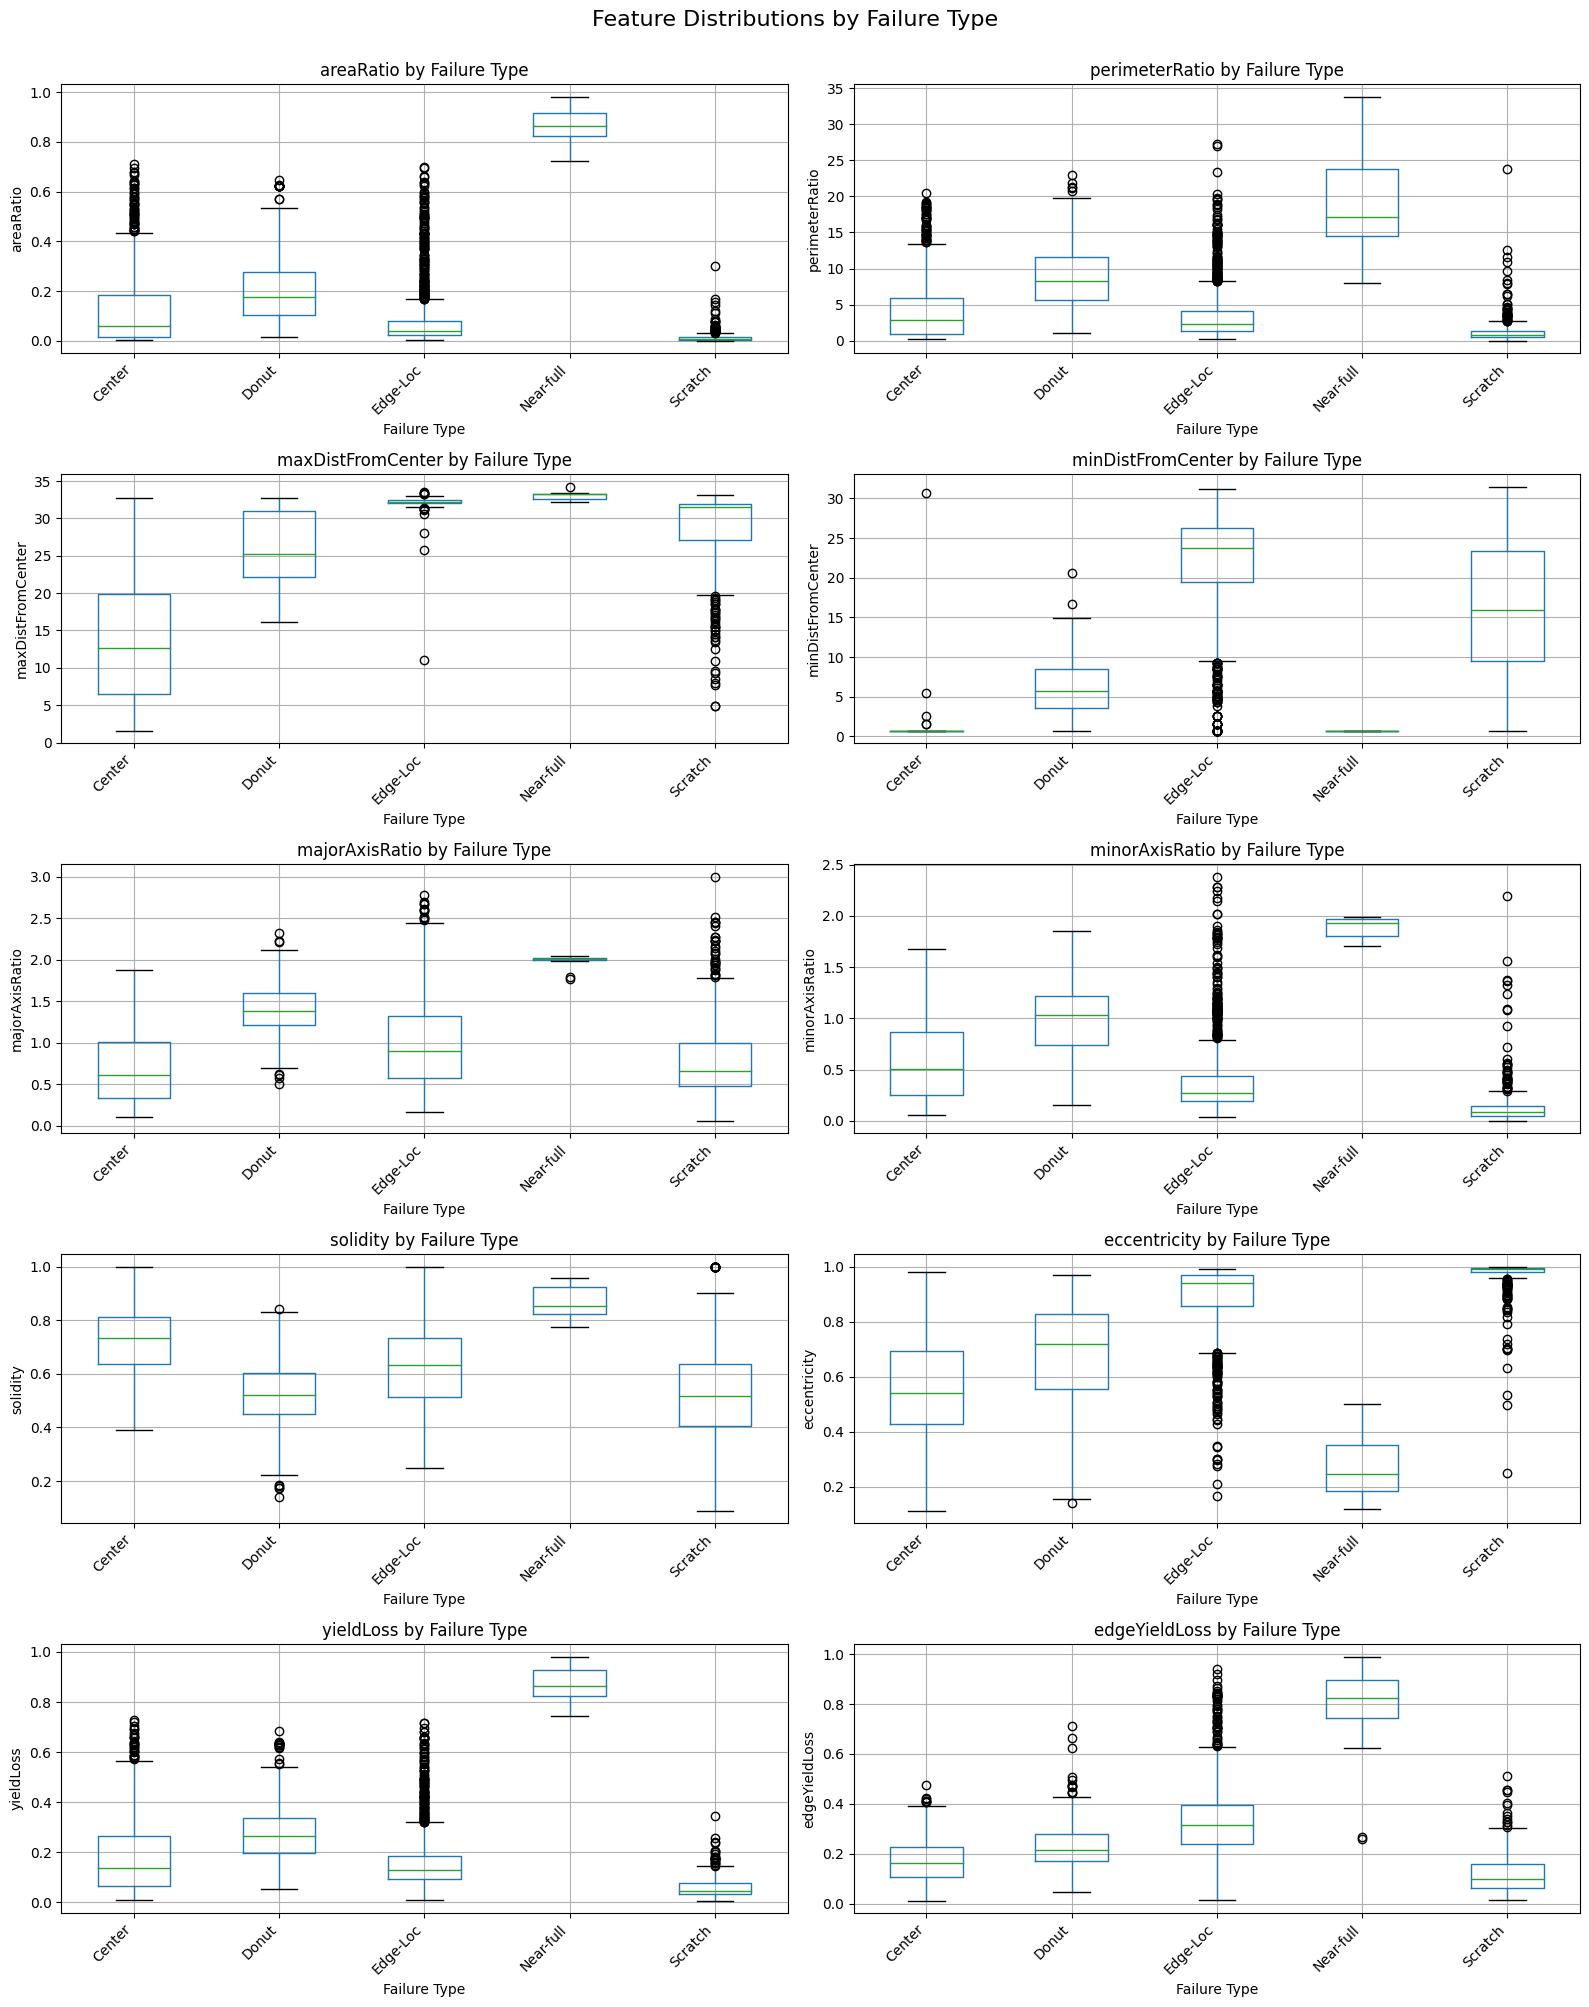

In [19]:
# Create box plots for all features
fig, axes = plt.subplots(5, 2, figsize=(16, 20))
axes = axes.flatten()

for idx, feature in enumerate(feature_cols):
    df_train.boxplot(column=feature, by='failureType', ax=axes[idx])
    axes[idx].set_title(f'{feature} by Failure Type')
    axes[idx].set_xlabel('Failure Type')
    axes[idx].set_ylabel(feature)
    plt.sca(axes[idx])
    plt.xticks(rotation=45, ha='right')

plt.suptitle('Feature Distributions by Failure Type', y=1.001, fontsize=16)
plt.tight_layout()
plt.show()

## 3. Model Training and Selection

We'll try multiple approaches:
1. **Baseline models** with all features
2. **Feature selection** based on importance
3. **Hyperparameter tuning** for best model

### 3.1 Prepare Data for Training

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Prepare features (X) and labels (y)
X = df_train[feature_cols].values
y = df_train['numericFailureType'].values

# Split into training and validation sets (80/20 split)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"\nClass distribution in training set:")
for failure_type, count in zip(*np.unique(y_train, return_counts=True)):
    print(f"  {int2string[failure_type]}: {count}")

Training set: 2196 samples
Validation set: 550 samples

Class distribution in training set:
  Center: 617
  Donut: 310
  Edge-Loc: 927
  Near-full: 12
  Scratch: 330


### 3.2 Baseline Models (All Features)

In [21]:
# Dictionary to store results
results = {}

# 1. Decision Tree (baseline)
print("Training Decision Tree...")
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

dt_train_acc = accuracy_score(y_train, dt_model.predict(X_train))
dt_val_acc = accuracy_score(y_val, dt_model.predict(X_val))

results['Decision Tree'] = {'train_acc': dt_train_acc, 'val_acc': dt_val_acc, 'model': dt_model}
print(f"  Training Accuracy: {dt_train_acc:.4f}")
print(f"  Validation Accuracy: {dt_val_acc:.4f}")

# 2. Random Forest
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf_model.predict(X_train))
rf_val_acc = accuracy_score(y_val, rf_model.predict(X_val))

results['Random Forest'] = {'train_acc': rf_train_acc, 'val_acc': rf_val_acc, 'model': rf_model}
print(f"  Training Accuracy: {rf_train_acc:.4f}")
print(f"  Validation Accuracy: {rf_val_acc:.4f}")

# 3. SVM with RBF kernel
print("\nTraining SVM (RBF kernel)...")
svm_model = SVC(kernel='rbf', random_state=42)
svm_model.fit(X_train, y_train)

svm_train_acc = accuracy_score(y_train, svm_model.predict(X_train))
svm_val_acc = accuracy_score(y_val, svm_model.predict(X_val))

results['SVM (RBF)'] = {'train_acc': svm_train_acc, 'val_acc': svm_val_acc, 'model': svm_model}
print(f"  Training Accuracy: {svm_train_acc:.4f}")
print(f"  Validation Accuracy: {svm_val_acc:.4f}")

# Summary
print("\n" + "="*60)
print("BASELINE MODEL COMPARISON (All 10 Features)")
print("="*60)
for model_name, model_results in results.items():
    print(f"{model_name:20s} | Train: {model_results['train_acc']:.4f} | Val: {model_results['val_acc']:.4f} | Overfit: {model_results['train_acc'] - model_results['val_acc']:.4f}")

Training Decision Tree...
  Training Accuracy: 1.0000
  Validation Accuracy: 0.9418

Training Random Forest...
  Training Accuracy: 1.0000
  Validation Accuracy: 0.9618

Training SVM (RBF kernel)...
  Training Accuracy: 0.8725
  Validation Accuracy: 0.8509

BASELINE MODEL COMPARISON (All 10 Features)
Decision Tree        | Train: 1.0000 | Val: 0.9418 | Overfit: 0.0582
Random Forest        | Train: 1.0000 | Val: 0.9618 | Overfit: 0.0382
SVM (RBF)            | Train: 0.8725 | Val: 0.8509 | Overfit: 0.0216


### 3.3 Feature Importance Analysis

Feature Importance (from Random Forest):
          feature  importance
minDistFromCenter    0.259743
maxDistFromCenter    0.200876
     eccentricity    0.159534
   minorAxisRatio    0.076237
    edgeYieldLoss    0.070011
         solidity    0.057525
        areaRatio    0.050856
        yieldLoss    0.043383
   perimeterRatio    0.041677
   majorAxisRatio    0.040157


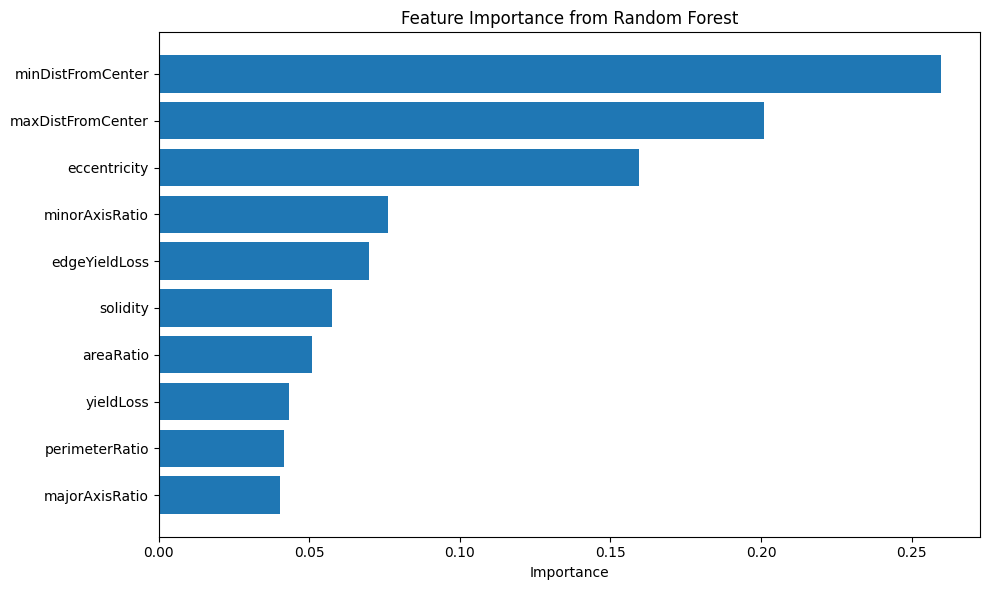


Top 9 features capturing 90% importance:
['minDistFromCenter', 'maxDistFromCenter', 'eccentricity', 'minorAxisRatio', 'edgeYieldLoss', 'solidity', 'areaRatio', 'yieldLoss', 'perimeterRatio']


In [22]:
# Analyze feature importance from Random Forest (best baseline model)
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Feature Importance (from Random Forest):")
print(feature_importance.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance['importance'])
plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.xlabel('Importance')
plt.title('Feature Importance from Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Identify top features (cumulative importance >= 90%)
cumsum = feature_importance['importance'].cumsum()
n_features_90 = (cumsum >= 0.90).idxmax() + 1
top_features = feature_importance.head(n_features_90)['feature'].tolist()

print(f"\nTop {n_features_90} features capturing 90% importance:")
print(top_features)

### 3.4 Hyperparameter Tuning

In [23]:
from sklearn.model_selection import GridSearchCV

# We'll tune Random Forest since it showed the best baseline performance
print("Tuning Random Forest hyperparameters...")
print("This may take a few minutes...\n")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

# Use GridSearchCV with cross-validation
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nBest parameters: {grid_search.best_params_}")
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Evaluate on validation set
best_rf_model = grid_search.best_estimator_
best_train_acc = accuracy_score(y_train, best_rf_model.predict(X_train))
best_val_acc = accuracy_score(y_val, best_rf_model.predict(X_val))

print(f"\nBest Model Performance:")
print(f"  Training Accuracy: {best_train_acc:.4f}")
print(f"  Validation Accuracy: {best_val_acc:.4f}")
print(f"  Overfitting Gap: {best_train_acc - best_val_acc:.4f}")

Tuning Random Forest hyperparameters...
This may take a few minutes...

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Best cross-validation score: 0.9668

Best Model Performance:
  Training Accuracy: 0.9945
  Validation Accuracy: 0.9600
  Overfitting Gap: 0.0345


### 3.5 Detailed Evaluation

Classification Report (Validation Set):
              precision    recall  f1-score   support

      Center       0.96      0.98      0.97       154
       Donut       0.96      0.90      0.93        78
    Edge-Loc       0.97      0.97      0.97       232
   Near-full       1.00      1.00      1.00         3
     Scratch       0.94      0.94      0.94        83

    accuracy                           0.96       550
   macro avg       0.97      0.96      0.96       550
weighted avg       0.96      0.96      0.96       550



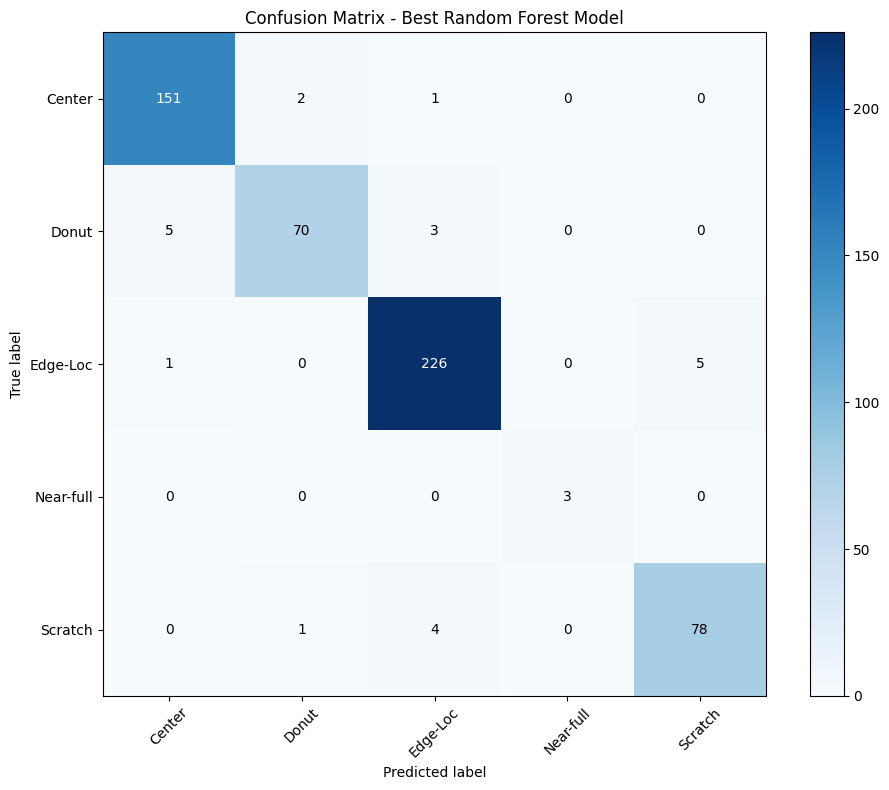

In [24]:
# Confusion matrix and classification report
y_pred = best_rf_model.predict(X_val)

print("Classification Report (Validation Set):")
print(classification_report(y_val, y_pred, target_names=[int2string[i] for i in range(5)]))

# Confusion matrix visualization
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Best Random Forest Model')
plt.colorbar()
tick_marks = np.arange(5)
plt.xticks(tick_marks, [int2string[i] for i in range(5)], rotation=45)
plt.yticks(tick_marks, [int2string[i] for i in range(5)])

# Add text annotations
thresh = cm.max() / 2.
for i, j in np.ndindex(cm.shape):
    plt.text(j, i, format(cm[i, j], 'd'),
             ha="center", va="center",
             color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.tight_layout()
plt.show()

### 3.6 Feature Selection Optimization

## 4. Test Set Prediction

### 4.1 Load and Prepare Test Data

In [25]:
# Load test data
data_test = np.load('data/wafermap_test.npy', allow_pickle=True)
df_test = pd.DataFrame(data_test)

print(f"Test set size: {len(df_test)}")
print(f"\nTest data columns: {df_test.columns.tolist()}")
print(f"\nFirst few rows:")
df_test.head()

Test set size: 2026

Test data columns: ['dieSize', 'lotName', 'trainTestLabel', 'waferIndex', 'waferMap']

First few rows:


,dieSize,lotName,trainTestLabel,waferIndex,waferMap
0,3031.0,lot41961,Test,1.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
1,3028.0,lot41962,Test,1.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
2,3025.0,lot41962,Test,18.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
3,3024.0,lot41967,Test,20.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."
4,1233.0,lot42448,Test,4.0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,..."


### 4.2 Apply Same Preprocessing and Feature Extraction

In [27]:
# Apply the same preprocessing steps as training data
print("Preprocessing test data...")

# 1. Resize wafer maps
df_test['resizedWaferMap'] = df_test['waferMap'].apply(lambda x: resize_wafer_map(x, output_shape=(64, 64)))

# 2. Extract salient regions (apply to each row)
df_test['salientRegion'] = df_test.apply(get_salient_region, axis=1)

print("✓ Preprocessing complete!")

# 3. Extract all features
print("\nExtracting features for test set...")
df_test = create_feature_columns(df_test)

print(f"✓ Feature extraction complete! Test DataFrame has {df_test.shape[1]} columns")
print(f"\nTest set ready with {len(df_test)} samples and {len(feature_cols)} features")

Preprocessing test data...
✓ Preprocessing complete!

Extracting features for test set...
Extracting features for all samples...
Total samples: 2026


/var/folders/_z/yccpmt615jbdbqdrx7z1t4xc0000gn/T/ipykernel_35105/126889431.py:139: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  eroded_once = binary_erosion(die_mask, square(3)).astype(int)
/var/folders/_z/yccpmt615jbdbqdrx7z1t4xc0000gn/T/ipykernel_35105/126889431.py:142: FutureWarning: `square` is deprecated since version 0.25 and will be removed in version 0.27. Use `skimage.morphology.footprint_rectangle` instead.
  eroded_twice = binary_erosion(eroded_once, square(3)).astype(int)


✓ Feature extraction complete!
✓ Feature extraction complete! Test DataFrame has 17 columns

Test set ready with 2026 samples and 10 features


### 4.3 Generate Predictions

In [28]:
# Extract features for prediction
X_test = df_test[feature_cols].values

# Generate predictions using the best model
predictions_numeric = best_rf_model.predict(X_test)

# Convert numeric predictions back to string labels
predictions_string = [int2string[pred] for pred in predictions_numeric]

# Create scores DataFrame
scores_df = pd.DataFrame({'failureType': predictions_string})

print(f"Generated {len(scores_df)} predictions")
print(f"\nPrediction distribution:")
print(scores_df['failureType'].value_counts().sort_index())
print(f"\nFirst 10 predictions:")
print(scores_df.head(10))

Generated 2026 predictions

Prediction distribution:
failureType
Center        294
Donut          46
Edge-Loc     1370
Near-full      26
Scratch       290
Name: count, dtype: int64

First 10 predictions:
  failureType
0      Center
1      Center
2      Center
3      Center
4      Center
5      Center
6      Center
7      Center
8      Center
9      Center


### 4.4 Save scores.csv

In [29]:
# Save to scores.csv
scores_df.to_csv('scores.csv', index=False)
print("✓ Saved predictions to scores.csv")

# Verify the file
import os
if os.path.exists('scores.csv'):
    file_size = os.path.getsize('scores.csv')
    print(f"✓ File created successfully ({file_size} bytes)")
    
    # Read back to verify format
    verify_df = pd.read_csv('scores.csv')
    print(f"✓ Verified: {len(verify_df)} rows, columns: {verify_df.columns.tolist()}")
else:
    print("✗ Error: File not created")

✓ Saved predictions to scores.csv
✓ File created successfully (17256 bytes)
✓ Verified: 2026 rows, columns: ['failureType']
